# Zero-DCE++ with SE-Block — clean rebuild (v10: multi-exposure training)

## Why this exists
v9 fixed the exposure ceiling (soft-clip, applied only post-curve) and the
noise-loss collapse. Real-world test photos still showed the network
overexposing already-well-lit input and never darkening blown-out input —
both symptoms of the actual root cause, not a loss-tuning problem: the
network is trained ONLY on LOL-v2's `Low` images, every single training
example dark. It has literally no training signal for "this is already
fine, leave it" or "this is too bright, darken it" -- any such input is
pure extrapolation, not a hard case within its learned distribution.

**v10 restores the original Zero-DCE design assumption** (the paper trains
on multi-exposure data specifically so the curve estimator learns
bidirectional, self-limiting behavior) using data already on disk, no new
collection needed:

1. **Normal-exposure stream** — LOL-v2's `Normal` images, already loaded
   every batch as evaluation ground truth, now ALSO pushed through the
   model as ordinary unpaired training input under the same zero-reference
   losses. Since they're already well-exposed, the exposure loss gradient
   there is naturally near zero -- this directly teaches "don't touch
   what's already correct" as an in-distribution behavior.
2. **Synthetic-overexposure stream** — `Normal` images multiplied by a
   random gain (1.5x-3.0x) and clamped, fed through the same model/loss.
   Teaches the network to use the DARKENING half of its curve range
   (`a>0` in this repo's convention), which it previously had zero
   incentive to ever use.

Each training step now runs three forward passes (dark / normal /
synthetic-overexposed) through the SAME model and SAME losses -- no new
loss terms, no new architecture, no paired supervision added. This is
roughly 3x the per-step compute of v9.

### 1. Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3060


### 2. SE-Block

Now configurable: `activation` controls the bottleneck's non-linearity
(`relu`, `prelu`, `silu`), `gate` controls the final channel-gate function
(`sigmoid`, `hardsigmoid`). Defaults (`relu`, `sigmoid`) exactly match the
v7 behavior, so nothing changes unless you deliberately pass a different
combination when constructing `DCENetLite`.

In [2]:
class SEBlock(nn.Module):
    _ACT = {
        'relu':  lambda: nn.ReLU(inplace=True),
        'prelu': lambda: nn.PReLU(),
        'silu':  lambda: nn.SiLU(inplace=True),   # aka Swish, used in EfficientNet's SE
        'gelu':  lambda: nn.GELU(),
    }
    _GATE = {
        'sigmoid':     lambda: nn.Sigmoid(),
        'hardsigmoid': lambda: nn.Hardsigmoid(inplace=True),  # used in MobileNetV3's SE
    }

    def __init__(self, channels, reduction=4, activation='relu', gate='sigmoid'):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            self._ACT[activation](),
            nn.Linear(channels // reduction, channels, bias=False),
            self._GATE[gate](),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w

print('SE-Block defined (activation/gate configurable; defaults match v7: relu/sigmoid)')

SE-Block defined (activation/gate configurable; defaults match v7: relu/sigmoid)


### 3. Depth-Separable Convolution + DCE-Net++

Unchanged from v8 except `enhance_image_with_curve`, which now takes
`max_exposure` (default `MAX_EXPOSURE = 0.95`, defined right above it).
As each curve iteration runs, only the *brightening* part of that step
(`a*(x^2-x) > 0` in this repo's sign convention) is smoothly damped as a
pixel approaches `max_exposure`; darkening is untouched. This guarantees no
pixel can exceed the ceiling regardless of what the network outputs --
including on well-lit inputs at inference, which is exactly the case this
was added for. Set `MAX_EXPOSURE` closer to 1.0 for a looser ceiling
(0.90-0.97 is a reasonable range to try).

In [3]:
class DepthSeparableConv2d(nn.Module):
    """Depthwise conv (per-channel spatial filter) + pointwise 1x1 (channel mixing).
    Matches TF's SeparableConv2D: depth_multiplier=1, RandomNormal(std=0.02) init."""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding,
                                    groups=in_channels, bias=True)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=True)
        nn.init.normal_(self.depthwise.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.pointwise.weight, mean=0.0, std=0.02)
        nn.init.zeros_(self.depthwise.bias)
        nn.init.zeros_(self.pointwise.bias)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class DCENetLite(nn.Module):
    """Zero-DCE++ backbone: depth-separable convs, SE-Block(s) placeable at any
    of conv1-conv4, single shared 3-channel curve map (not per-iteration 24-channel)."""
    def __init__(self, filters=32, use_attention=True, se_positions=(3,),
                 reduction=4, se_activation='relu', se_gate='sigmoid', iterations=8):
        super().__init__()
        self.use_attention = use_attention
        self.se_positions  = set(se_positions) if use_attention else set()
        self.iterations    = iterations

        self.conv1 = DepthSeparableConv2d(3,          filters)
        self.conv2 = DepthSeparableConv2d(filters,    filters)
        self.conv3 = DepthSeparableConv2d(filters,    filters)
        self.conv4 = DepthSeparableConv2d(filters,    filters)
        self.conv5 = DepthSeparableConv2d(filters*2,  filters)  # concat(x3, x4)
        self.conv6 = DepthSeparableConv2d(filters*2,  filters)  # concat(x2, x5)
        self.conv7 = DepthSeparableConv2d(filters*2,  3)        # concat(x1, x6) -> 3ch only
        self.relu  = nn.ReLU(inplace=True)

        if use_attention:
            self.se_blocks = nn.ModuleDict({
                str(pos): SEBlock(filters, reduction=reduction,
                                   activation=se_activation, gate=se_gate)
                for pos in self.se_positions
            })

    def _se(self, feat, pos):
        if pos in self.se_positions:
            return self.se_blocks[str(pos)](feat)
        return feat

    def forward(self, x):
        x1 = self._se(self.relu(self.conv1(x)),  1)
        x2 = self._se(self.relu(self.conv2(x1)), 2)
        x3 = self._se(self.relu(self.conv3(x2)), 3)
        x4 = self._se(self.relu(self.conv4(x3)), 4)
        x5 = self.relu(self.conv5(torch.cat([x3, x4], 1)))
        x6 = self.relu(self.conv6(torch.cat([x2, x5], 1)))
        a_map = torch.tanh(self.conv7(torch.cat([x1, x6], 1)))  # [B, 3, H, W]
        return a_map


MAX_EXPOSURE = 0.95  # ceiling: no pixel can be pushed brighter than this by the curve steps

def enhance_image_with_curve(x, a_map, iterations=8, max_exposure=0.95, knee=0.10):
    """Curve identical to v7/no-ceiling behavior. A soft ceiling is applied
    only at the very end, only to pixels within `knee` of full brightness --
    everything below (max_exposure - knee) passes through completely
    unchanged, so normal LOL-v2 training dynamics (which converge around
    ~0.5) are untouched. Only genuinely near-blown-out pixels get gently
    compressed toward max_exposure, which is the actual overexposure case
    this is meant to guard against."""
    enhanced = x
    for _ in range(iterations):
        enhanced = enhanced + a_map * (enhanced.pow(2) - enhanced)
    enhanced = torch.clamp(enhanced, 0.0, 1.0)

    threshold = max_exposure - knee
    over = (enhanced > threshold).float()
    t = ((enhanced - threshold) / (1.0 - threshold + 1e-8)).clamp(0, 1)
    compressed = threshold + knee * (1.0 - torch.exp(-3.0 * t))
    compressed = torch.minimum(compressed, torch.full_like(enhanced, max_exposure))

    return enhanced * (1 - over) + compressed * over


# se_positions=(3,), reduction=4, se_activation='relu', se_gate='sigmoid'
# reproduces v7's SE config exactly. Change any of these for the ablation table.
model = DCENetLite(use_attention=True, se_positions=(3,),
                    reduction=4, se_activation='relu', se_gate='sigmoid').to(device)
print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')
print(f'MAX_EXPOSURE ceiling: {MAX_EXPOSURE}')

Model: 11,073 parameters
MAX_EXPOSURE ceiling: 0.95


### 4. Loss Functions (ported from tested TF reference) + noise-suppression term + adaptive exposure

Two changes from v8:

- **`ExposureControlLoss`** now takes the input image too. If an input patch
  is already at or above the target brightness `e`, the target becomes the
  input's own level (i.e. "don't push further") instead of always demanding
  `e=0.52` -- this is what teaches the network to hold back on already-bright
  input rather than only being capped after the fact by `MAX_EXPOSURE`.
- **`NoiseSuppressionLoss`** rewritten to fix the mode-collapse bug from the
  last run: it now penalizes the *increase* in local variation from input to
  enhanced (never negative, so its minimum is "no added noise", not "flat
  image"), and dark-region weighting uses a threshold instead of
  `(1 - input.mean())`. `w_noise` lowered to 5.0 and ramped in via a 20-epoch
  warm-up in the training loop below (`loss_fn.w_noise` starts at 0 and
  reaches 5.0 by epoch 20), so it has no effect until the other four terms
  have already stabilized, exactly like v7 behaved before any noise term
  existed.

In [4]:
class SpatialConsistencyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        k_left  = torch.tensor([[0.,0.,0.],[-1.,1.,0.],[0.,0.,0.]]).view(1,1,3,3)
        k_right = torch.tensor([[0.,0.,0.],[0.,1.,-1.],[0.,0.,0.]]).view(1,1,3,3)
        k_up    = torch.tensor([[0.,-1.,0.],[0.,1.,0.],[0.,0.,0.]]).view(1,1,3,3)
        k_down  = torch.tensor([[0.,0.,0.],[0.,1.,0.],[0.,-1.,0.]]).view(1,1,3,3)
        self.register_buffer('k_left',  k_left)
        self.register_buffer('k_right', k_right)
        self.register_buffer('k_up',    k_up)
        self.register_buffer('k_down',  k_down)
        self.pool = nn.AvgPool2d(kernel_size=4, stride=4)

    def forward(self, inp, enh):
        inp_mean = inp.mean(dim=1, keepdim=True)
        enh_mean = enh.mean(dim=1, keepdim=True)
        inp_pool = self.pool(inp_mean)
        enh_pool = self.pool(enh_mean)

        d_inp = [F.conv2d(inp_pool, k, padding=1) for k in
                 (self.k_left, self.k_right, self.k_up, self.k_down)]
        d_enh = [F.conv2d(enh_pool, k, padding=1) for k in
                 (self.k_left, self.k_right, self.k_up, self.k_down)]

        return sum((di - de).pow(2) for di, de in zip(d_inp, d_enh)).mean()


class ExposureControlLoss(nn.Module):
    """Target brightness now adapts toward the input's own level when the
    input patch is already at/above target, instead of always demanding
    e=0.52 regardless of the input's own brightness. This is what teaches
    the network to hold back on already-bright input, complementing the
    hard MAX_EXPOSURE ceiling in enhance_image_with_curve."""
    def __init__(self, e=0.52, patch_size=16):
        super().__init__()
        self.e = e
        self.pool = nn.AvgPool2d(kernel_size=patch_size, stride=patch_size)

    def forward(self, enhanced, input_img):
        mean_c       = enhanced.mean(dim=1, keepdim=True)
        input_c      = input_img.mean(dim=1, keepdim=True)
        pooled       = self.pool(mean_c)
        input_pooled = self.pool(input_c)
        target = torch.where(input_pooled >= self.e, input_pooled,
                              torch.full_like(input_pooled, self.e))
        return (pooled - target).pow(2).mean()


class ColorConstancyLoss(nn.Module):
    def forward(self, enhanced):
        mean_rgb = enhanced.mean(dim=[2, 3], keepdim=True)  # [B, 3, 1, 1]
        mr, mg, mb = mean_rgb[:, 0:1], mean_rgb[:, 1:2], mean_rgb[:, 2:3]
        d_rg = (mr - mg).pow(2)
        d_rb = (mr - mb).pow(2)
        d_gb = (mb - mg).pow(2)
        return torch.sqrt(d_rg + d_rb + d_gb + 1e-8).mean()


class IlluminationSmoothnessLoss(nn.Module):
    def forward(self, alpha_map):
        b, c, h, w = alpha_map.shape
        count_h = (w - 1) * c
        count_w = w * (c - 1)

        tv_h = (alpha_map[:, :, 1:, :] - alpha_map[:, :, :h-1, :]).pow(2).sum() / count_h
        tv_w = (alpha_map[:, :, :, 1:] - alpha_map[:, :, :, :w-1]).pow(2).sum() / count_w

        return 2 * (tv_h + tv_w) / b


class NoiseSuppressionLoss(nn.Module):
    """Penalizes the INCREASE in local pixel variation from input to enhanced
    (not the enhanced image's raw variation), so it can't be minimized by
    flattening the whole image to black -- its minimum is reached when
    enhanced's local texture matches the input's. Dark-region weighting uses
    a threshold (dark_threshold) rather than (1 - mean), since for a
    low-light dataset nearly the whole frame is dark and (1-mean) ends up
    weighting almost everything near 1."""
    def __init__(self, dark_threshold=0.3):
        super().__init__()
        self.dark_threshold = dark_threshold

    def forward(self, enhanced, input_img):
        def grad(t):
            gh = (t[:, :, 1:, :] - t[:, :, :-1, :]).abs()
            gw = (t[:, :, :, 1:] - t[:, :, :, :-1]).abs()
            return gh, gw

        enh_gh, enh_gw = grad(enhanced)
        inp_gh, inp_gw = grad(input_img)

        excess_h = (enh_gh - inp_gh).clamp(min=0)
        excess_w = (enh_gw - inp_gw).clamp(min=0)

        input_mean  = input_img.mean(dim=1, keepdim=True)
        dark_weight = torch.clamp((self.dark_threshold - input_mean) / self.dark_threshold, 0, 1)

        return (excess_h * dark_weight[:, :, 1:, :]).mean() + (excess_w * dark_weight[:, :, :, 1:]).mean()


class DenoiseHead(nn.Module):
    """Lightweight learned denoiser applied after curve enhancement.
    Depthwise-separable, residual, output scaled small (x0.1) so it corrects
    noise rather than repainting the image."""
    def __init__(self, channels=16):
        super().__init__()
        self.conv1 = DepthSeparableConv2d(3, channels)
        self.conv2 = DepthSeparableConv2d(channels, 3)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, enhanced):
        residual = self.relu(self.conv1(enhanced))
        residual = torch.tanh(self.conv2(residual)) * 0.1
        return torch.clamp(enhanced + residual, 0, 1)


class ZeroDCELoss(nn.Module):
    """Combines all four zero-reference terms (reference repo's LITE weights,
    as tuned in v7) plus a noise-suppression term, ramped in via warm-up."""
    def __init__(self, e=0.52, patch_size=16,
                 w_spa=5.0, w_exp=20.0, w_col=5.0, w_ill=400.0, w_noise=5.0):
        super().__init__()
        self.spa = SpatialConsistencyLoss()
        self.exp = ExposureControlLoss(e=e, patch_size=patch_size)
        self.col = ColorConstancyLoss()
        self.ill = IlluminationSmoothnessLoss()
        self.w_spa, self.w_exp, self.w_col, self.w_ill, self.w_noise = \
            w_spa, w_exp, w_col, w_ill, w_noise

    def forward(self, enhanced, input_img, a_map, l_noise=None):
        l_spa = self.spa(input_img, enhanced)
        l_exp = self.exp(enhanced, input_img)
        l_col = self.col(enhanced)
        l_ill = self.ill(a_map)
        if l_noise is None:
            l_noise = torch.zeros((), device=enhanced.device)
        total = (self.w_spa * l_spa + self.w_exp * l_exp
                 + self.w_col * l_col + self.w_ill * l_ill
                 + self.w_noise * l_noise)
        return total, l_spa, l_exp, l_col, l_ill, l_noise

loss_fn       = ZeroDCELoss().to(device)
noise_loss_fn = NoiseSuppressionLoss().to(device)
denoise_head  = DenoiseHead().to(device)
print('Loss functions defined (lite weights: spa=5, exp=20, col=5, ill=400, noise=5 [ramped])')
print(f'DenoiseHead: {sum(p.numel() for p in denoise_head.parameters()):,} parameters')

Loss functions defined (lite weights: spa=5, exp=20, col=5, ill=400, noise=5 [ramped])
DenoiseHead: 305 parameters


### 5. Dataset (LOL-v2 Real_captured, paired Low/Normal)

Unchanged loading/augmentation. One behavioral note: `normal` was always
loaded in every batch (previously only used as eval ground truth) — v10's
training loop now also feeds it to the model directly as a second training
stream, plus a synthetically-overexposed third stream derived from it. No
dataset changes needed here, only how the training loop in Section 6 uses
what's already being loaded.

In [5]:
class LOLDataset(Dataset):
    def __init__(self, image_pairs, img_size=512, augment=False):
        self.image_pairs = image_pairs
        self.img_size    = img_size
        self.augment     = augment
        self.resize_size = int(img_size * 1.15)

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        pair = self.image_pairs[idx]
        low_img    = Image.open(pair['low']).convert('RGB')
        normal_img = Image.open(pair['normal']).convert('RGB')

        # Resize by SHORT SIDE — preserves aspect ratio
        low_img    = TF.resize(low_img,    self.resize_size, interpolation=Image.BILINEAR)
        normal_img = TF.resize(normal_img, self.resize_size, interpolation=Image.BILINEAR)

        if self.augment:
            i, j, h, w = transforms.RandomCrop.get_params(
                low_img, (self.img_size, self.img_size))
            low_img    = TF.crop(low_img,    i, j, h, w)
            normal_img = TF.crop(normal_img, i, j, h, w)
            if torch.rand(1) > 0.5:
                low_img    = TF.hflip(low_img)
                normal_img = TF.hflip(normal_img)
        else:
            low_img    = TF.center_crop(low_img,    self.img_size)
            normal_img = TF.center_crop(normal_img, self.img_size)

        return {
            'low':      TF.to_tensor(low_img),
            'normal':   TF.to_tensor(normal_img),
            'filename': pair['filename']
        }

def load_image_pairs(data_path):
    low_p  = data_path / 'Low'
    norm_p = data_path / 'Normal'
    lows   = sorted([f for f in os.listdir(low_p)  if f.endswith(('.jpg','.png'))])
    norms  = sorted([f for f in os.listdir(norm_p) if f.endswith(('.jpg','.png'))])
    assert len(lows)==len(norms), f'Pair mismatch: {len(lows)} vs {len(norms)}'
    return [{'low':str(low_p/l),'normal':str(norm_p/n),'filename':l}
            for l,n in zip(lows,norms)]

BASE_PATH    = Path('LOL-v2')
train_pairs  = load_image_pairs(BASE_PATH / 'Real_captured' / 'Train')
test_pairs   = load_image_pairs(BASE_PATH / 'Real_captured' / 'Test')
print(f'LOL-v2: {len(train_pairs)} train, {len(test_pairs)} test')

BATCH_SIZE  = 8
IMG_SIZE    = 512
train_loader = DataLoader(LOLDataset(train_pairs, IMG_SIZE, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(LOLDataset(test_pairs,  IMG_SIZE, augment=False),
                          batch_size=1,          shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

LOL-v2: 689 train, 100 test
Train batches: 87 | Test batches: 100


### 6. Training

Same structure as v9 (gradient accumulation, collapse guard, early
stopping, noise loss detached from the curve network, 20-epoch warm-up).
New: each step also runs the `normal` batch and a synthetically
overexposed version of it through the same model and loss function
(`synthetic_overexpose`, `W_NORMAL_STREAM`, `W_OVER_STREAM` below), so the
network is trained on all three exposure regimes every step, not just dark
input. `history` now also tracks `loss_normal` and `loss_over` per epoch so
you can see each stream converging separately.

In [6]:
def synthetic_overexpose(img, gain_range=(1.5, 3.0)):
    """Randomly blows out an already-normal image to create a free
    'overexposed' training example -- teaches the network to use the
    darkening half of its curve range (a>0 in this repo's sign
    convention), which it otherwise has zero incentive to ever learn."""
    gain = torch.empty(img.size(0), 1, 1, 1, device=img.device).uniform_(*gain_range)
    return torch.clamp(img * gain, 0, 1)


LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5
NUM_EPOCHS    = 200
PATIENCE      = 35
ACCUM_STEPS   = 2
NOISE_WARMUP_EPOCHS = 20
NOISE_TARGET_WEIGHT = 5.0
W_NORMAL_STREAM = 1.0   # weight of the "leave it alone" stream
W_OVER_STREAM   = 1.0   # weight of the "darken this" stream
CHECKPOINT    = 'best_zerodce_pp_seblock_v10.pth'

optimizer = optim.Adam(list(model.parameters()) + list(denoise_head.parameters()),
                        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

history = {'loss':[],'spa':[],'exp':[],'col':[],'ill':[],'noise':[],
           'loss_normal':[],'loss_over':[],'lr':[]}
best_loss     = float('inf')
no_improve    = 0
stopped_epoch = NUM_EPOCHS

print(f"{'='*60}")
print(f'TRAINING Zero-DCE++ (depth-separable) + SE-Block + DenoiseHead + multi-exposure \u2014 max {NUM_EPOCHS} epochs, patience={PATIENCE}')
print(f'Effective batch: {BATCH_SIZE}\u00d7{ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}')
print(f'MAX_EXPOSURE ceiling: {MAX_EXPOSURE} | Noise warm-up: {NOISE_WARMUP_EPOCHS} epochs -> w_noise={NOISE_TARGET_WEIGHT}')
print(f'Streams per step: dark (w=1.0) + normal (w={W_NORMAL_STREAM}) + synthetic-overexposed (w={W_OVER_STREAM})')
print(f"{'='*60}")

for epoch in range(NUM_EPOCHS):
    model.train()
    denoise_head.train()
    totals = dict(loss=0, spa=0, exp=0, col=0, ill=0, noise=0, loss_normal=0, loss_over=0)

    loss_fn.w_noise = NOISE_TARGET_WEIGHT * min(1.0, epoch / NOISE_WARMUP_EPOCHS)

    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'[{epoch+1}/{NUM_EPOCHS}]')

    for step, batch in pbar:
        low_imgs    = batch['low'].to(device)
        normal_imgs = batch['normal'].to(device)

        # --- Stream 1: genuinely dark input (teaches brightening) ---
        # backward() right after each stream frees its activation graph before
        # the next stream's forward pass starts -- holding all 3 graphs at
        # once (summing losses, one backward call) is what caused the OOM.
        a_map        = model(low_imgs)
        enhanced_pre = enhance_image_with_curve(low_imgs, a_map)
        enhanced     = denoise_head(enhanced_pre)
        l_noise      = noise_loss_fn(denoise_head(enhanced_pre.detach()), low_imgs)
        loss_low, l_spa, l_exp, l_col, l_ill, l_noise = loss_fn(enhanced, low_imgs, a_map, l_noise)
        (loss_low / ACCUM_STEPS).backward()

        # --- Stream 2: already-correct input (teaches "leave it alone") ---
        a_map_n        = model(normal_imgs)
        enhanced_n_pre = enhance_image_with_curve(normal_imgs, a_map_n)
        enhanced_n     = denoise_head(enhanced_n_pre)
        loss_normal, *_ = loss_fn(enhanced_n, normal_imgs, a_map_n)
        (W_NORMAL_STREAM * loss_normal / ACCUM_STEPS).backward()

        # --- Stream 3: synthetically overexposed input (teaches darkening) ---
        over_imgs      = synthetic_overexpose(normal_imgs)
        a_map_o        = model(over_imgs)
        enhanced_o_pre = enhance_image_with_curve(over_imgs, a_map_o)
        enhanced_o     = denoise_head(enhanced_o_pre)
        loss_over, *_  = loss_fn(enhanced_o, over_imgs, a_map_o)
        (W_OVER_STREAM * loss_over / ACCUM_STEPS).backward()

        loss = loss_low + W_NORMAL_STREAM * loss_normal + W_OVER_STREAM * loss_over  # logging only

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(
                list(model.parameters()) + list(denoise_head.parameters()), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        totals['loss']        += loss.item()
        totals['spa']         += l_spa.item()
        totals['exp']         += l_exp.item()
        totals['col']         += l_col.item()
        totals['ill']         += l_ill.item()
        totals['noise']       += l_noise.item()
        totals['loss_normal'] += loss_normal.item()
        totals['loss_over']   += loss_over.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'exp': f'{l_exp.item():.4f}',
                           'normal': f'{loss_normal.item():.4f}', 'over': f'{loss_over.item():.4f}'})

    n = len(train_loader)
    avg_loss = totals['loss'] / n
    for k in ['loss','spa','exp','col','ill','noise','loss_normal','loss_over']:
        history[k].append(totals[k] / n)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Collapse guard: check mean brightness every 10 epochs (dark stream, as before)
    if (epoch + 1) % 10 == 0:
        model.eval(); denoise_head.eval()
        with torch.no_grad():
            sample = next(iter(train_loader))['low'].to(device)
            a_s    = model(sample)
            e_s    = denoise_head(enhance_image_with_curve(sample, a_s))
            mean_brightness = e_s.mean().item()
        model.train(); denoise_head.train()
        print(f'  [Epoch {epoch+1}] mean_brightness={mean_brightness:.4f}', end='')
        if mean_brightness < 0.1:
            print(' \u2014 COLLAPSE DETECTED, stopping!')
            stopped_epoch = epoch + 1
            break
        else:
            print(f' | no_improve={no_improve}/{PATIENCE}')

    # Early stopping
    if avg_loss < best_loss:
        best_loss  = avg_loss
        no_improve = 0
        torch.save({'model': model.state_dict(),
                     'denoise_head': denoise_head.state_dict()}, CHECKPOINT)
        print(f'  Epoch {epoch+1}: loss={avg_loss:.6f}  [BEST saved]')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            stopped_epoch = epoch + 1
            print(f'  Early stopping at epoch {stopped_epoch}')
            break

    scheduler.step()

print(f"\n{'='*60}")
print(f'DONE \u2014 best loss: {best_loss:.6f} | stopped at epoch: {stopped_epoch}')
print(f"{'='*60}")

TRAINING Zero-DCE++ (depth-separable) + SE-Block + DenoiseHead + multi-exposure — max 200 epochs, patience=35
Effective batch: 8×2 = 16
MAX_EXPOSURE ceiling: 0.95 | Noise warm-up: 20 epochs -> w_noise=5.0
Streams per step: dark (w=1.0) + normal (w=1.0) + synthetic-overexposed (w=1.0)


[1/200]: 100%|██████████| 87/87 [02:21<00:00,  1.63s/it, loss=7.5679, exp=0.2107, normal=2.0925, over=1.1427]


  Epoch 1: loss=6.389978  [BEST saved]


[2/200]: 100%|██████████| 87/87 [01:44<00:00,  1.20s/it, loss=5.6671, exp=0.1989, normal=1.0256, over=0.5907]


  Epoch 2: loss=6.231620  [BEST saved]


...

  [Epoch 160] mean_brightness=0.2150 | no_improve=20/35


[170/200]: 100%|██████████| 87/87 [01:43<00:00,  1.19s/it, loss=1.8894, exp=0.0151, normal=0.6960, over=0.5140]


  [Epoch 170] mean_brightness=0.3082 | no_improve=30/35


[174/200]: 100%|██████████| 87/87 [01:44<00:00,  1.20s/it, loss=3.2103, exp=0.0088, normal=1.3305, over=0.6779]

  Early stopping at epoch 174

DONE — best loss: 3.402436 | stopped at epoch: 174


### 7. Training Curves

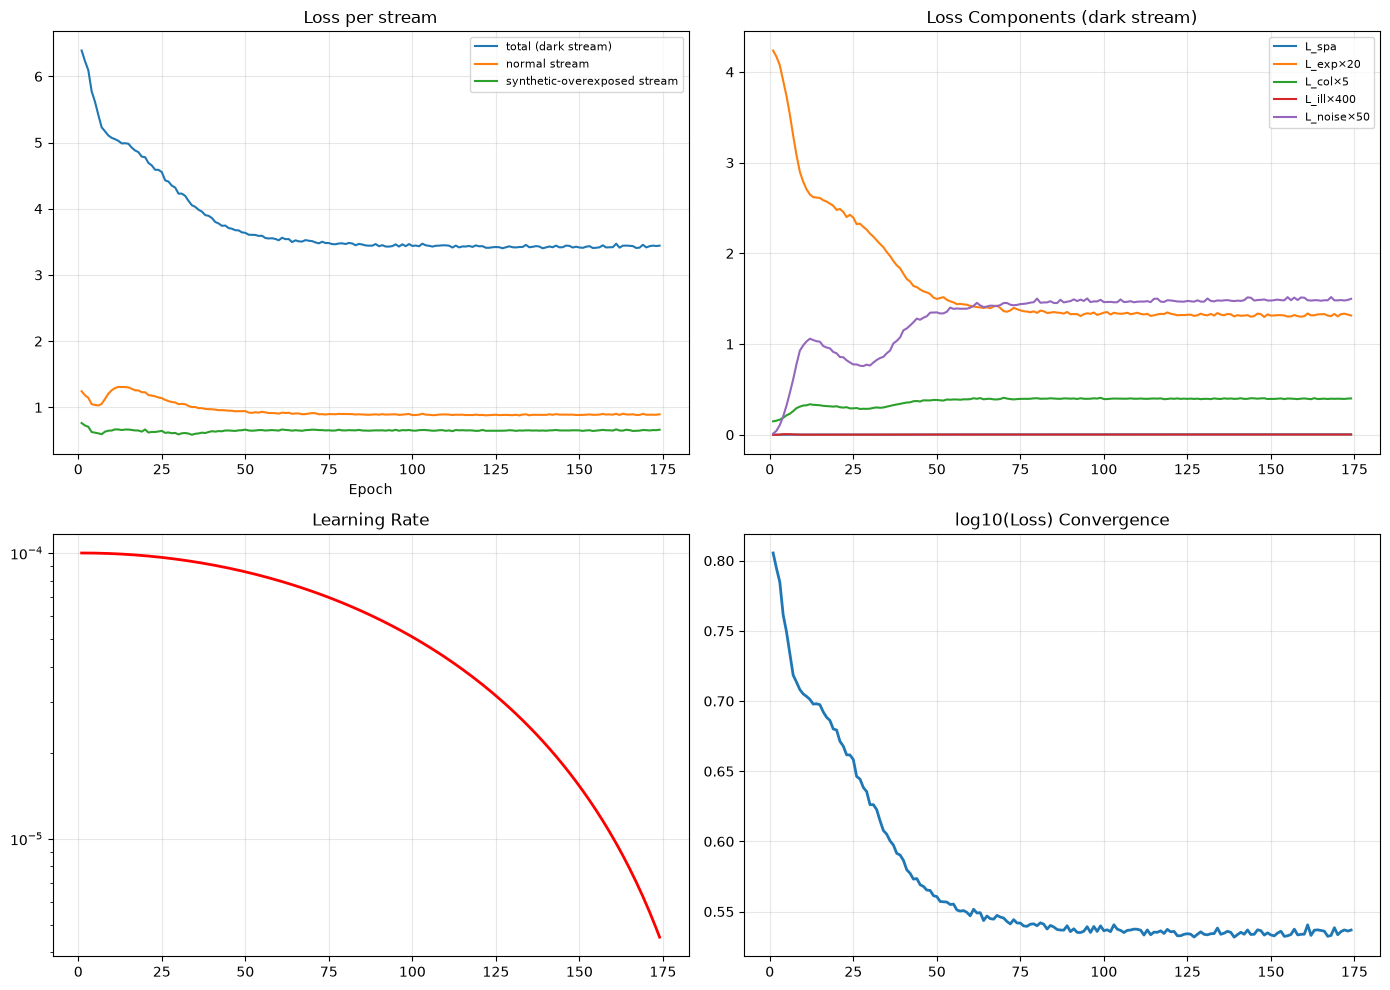

Saved: training_history_pp.png
Final: loss_normal=0.8946 (lower = better at leaving correct images alone)
Final: loss_over=0.6617 (lower = better at darkening blown-out images)


In [7]:
ep = range(1, len(history['loss'])+1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(ep, history['loss'],        label='total (dark stream)')
axes[0,0].plot(ep, history['loss_normal'], label='normal stream')
axes[0,0].plot(ep, history['loss_over'],   label='synthetic-overexposed stream')
axes[0,0].set_title('Loss per stream'); axes[0,0].set_xlabel('Epoch')
axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(ep, history['spa'],                    label='L_spa')
axes[0,1].plot(ep, np.array(history['exp'])*20,       label='L_exp\u00d720')
axes[0,1].plot(ep, np.array(history['col'])*5,        label='L_col\u00d75')
axes[0,1].plot(ep, np.array(history['ill'])*400,      label='L_ill\u00d7400')
axes[0,1].plot(ep, np.array(history['noise'])*50,     label='L_noise\u00d750')
axes[0,1].set_title('Loss Components (dark stream)')
axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)

axes[1,0].semilogy(ep, history['lr'], color='red', linewidth=2)
axes[1,0].set_title('Learning Rate'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(ep, np.log10(np.array(history['loss'])+1e-8), linewidth=2)
axes[1,1].set_title('log10(Loss) Convergence'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_pp.png', dpi=150)
plt.show()
print('Saved: training_history_pp.png')
print(f'Final: loss_normal={history["loss_normal"][-1]:.4f} (lower = better at leaving correct images alone)')
print(f'Final: loss_over={history["loss_over"][-1]:.4f} (lower = better at darkening blown-out images)')

### 8. Inference — trained denoiser + optional bilateral filter

The denoiser is now trained, not just applied at inference. `denoise=True`
still runs an additional bilateral filter pass on top for real-world photos
if you want extra smoothing; set it `False` to evaluate the model's own
learned denoising alone (e.g. for PSNR/SSIM against LOL-v2's Normal set).

In [9]:
def enhance_single_image(image_path, checkpoint=CHECKPOINT,
                          se_positions=(3,), reduction=4,
                          se_activation='relu', se_gate='sigmoid',
                          denoise=True, d=9, sigma_color=75, sigma_space=75):
    ckpt = torch.load(checkpoint, map_location=device)

    m = DCENetLite(use_attention=True, se_positions=se_positions, reduction=reduction,
                   se_activation=se_activation, se_gate=se_gate).to(device)
    m.load_state_dict(ckpt['model'])
    m.eval()

    dn = DenoiseHead().to(device)
    dn.load_state_dict(ckpt['denoise_head'])
    dn.eval()

    img = Image.open(image_path).convert('RGB')
    inp = TF.to_tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        enh = dn(enhance_image_with_curve(inp, m(inp)))

    enh_np = (enh.squeeze(0).cpu().permute(1,2,0).numpy()*255).astype(np.uint8)

    if denoise:
        bgr    = cv2.cvtColor(enh_np, cv2.COLOR_RGB2BGR)
        bgr    = cv2.bilateralFilter(bgr, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        enh_np = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(np.array(img)); axes[0].set_title('Input (low-light)');  axes[0].axis('off')
    axes[1].imshow(enh_np);        axes[1].set_title('Enhanced (Zero-DCE++ + DenoiseHead)' + (' + Bilateral' if denoise else ''))
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('inference_pp.png', dpi=150)
    plt.show()
    return enh_np

print('Usage:')
print('  enhance_single_image(\"your_photo.jpg\", denoise=True)   # real-world photos, extra smoothing on top')
print('  enhance_single_image(\"lolv2_test.jpg\", denoise=False)  # metric evaluation, learned denoiser only')
print('  # match se_positions/reduction/se_activation/se_gate to whatever CHECKPOINT was trained with')

Usage:
  enhance_single_image("your_photo.jpg", denoise=True)   # real-world photos, extra smoothing on top
  enhance_single_image("lolv2_test.jpg", denoise=False)  # metric evaluation, learned denoiser only
  # match se_positions/reduction/se_activation/se_gate to whatever CHECKPOINT was trained with


---
### Version History

| Version | Key issue | Status |
|---|---|---|
| v1 (original) | `tanh*0.15`, wrong loss weights, broken pairing | Fixed in v2 |
| v2 | Working baseline | Good |
| v3 | `L_tv_enh` weight=500 \u2192 mode collapse to black | **Broken** |
| v4 | `L_tv_enh` removed, exposure upgraded to per-patch MSE, collapse guard added | Good (standard convs, 24-ch curve = original Zero-DCE architecture) |
| v5 | Added `DPEDColorLoss` + `VGGContentLoss` (LOL-v2 GT), single optimizer | Improved metrics, green-cast bias persisted |
| v6 | Added `ChannelBalanceLoss` \u2014 direct per-channel mean matching | Targeted fix for the cast |
| v7 | Hybrid losses removed. Depth-separable convs + single shared 3-channel curve (genuine Zero-DCE++). SE-Block fixed after Conv3. | Good (baseline before v8) |
| v8 | SE-Block placement/activation configurable. Added trained `DenoiseHead` + `NoiseSuppressionLoss`. | **Broken** \u2014 noise loss's minimum was a flat/black image; collapsed by epoch 10 |
| v9 | `NoiseSuppressionLoss` rewritten (excess-gradient, threshold weighting, warm-up), noise loss detached from curve network. `MAX_EXPOSURE` soft-ceiling (post-curve, threshold+knee) replacing the flawed per-iteration headroom damping. Adaptive `ExposureControlLoss` target. | PSNR 20.06 / SSIM 0.696 / LPIPS 0.265 all pass targets on LOL-v2 test; NIQE still fails. Real-world test photos still overexposed well-lit input and never darkened blown-out input. |
| **v10 (this notebook)** | Root cause addressed: training was 100% dark-image-only, so the network had no signal for "leave this alone" or "darken this" \u2014 any such input was pure extrapolation. Added two training streams reusing already-loaded `Normal` images (unpaired, same zero-reference losses) plus a synthetic-overexposure augmentation, restoring the original Zero-DCE paper's multi-exposure training assumption. \u00d73 compute per step; no new data or loss terms. | **Current** \u2014 needs a v9-vs-v10 ablation (LOL-v2 metrics + brightness-drift robustness check) to confirm |

**Reminder:** BAB II \u00a72.2.2 / Rumus 2.1 architecture-description caveat still applies
(single shared 3-channel curve, not 24-channel). If keeping v10's multi-exposure
training, this is likely your strongest, most defensible novelty claim of everything
added since v7 \u2014 it's a root-cause fix to a named, demonstrable failure mode
(extrapolation to out-of-training-distribution exposure), restores a documented
design property of the original paper, and is directly measurable (brightness drift
on normal/overexposed input, not just LOL-v2 PSNR/SSIM). Report the v9-vs-v10
ablation explicitly \u2014 it's the evidence this claim needs.
